# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [43]:
# %% [markdown]
# # Deep Learning Assignment 1

# %%
%matplotlib inline
import os, itertools, random, copy, gc, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import optuna
from optuna.pruners import MedianPruner

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

notebook_dir = Path.cwd()
DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs"
MODEL_SAVE_DIR = OUTPUTS_DIR / "models"

# ONLY DEFINED ONCE HERE!
RESULTS_PATH = OUTPUTS_DIR / "phase_a_grid_results.pkl" 

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Weights will be saved to: {MODEL_SAVE_DIR}")

Using device: cuda
Weights will be saved to: /home/raveco/deep_learning_ass1/outputs/models


In [44]:
# %%
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(42)
g = torch.Generator()
g.manual_seed(42)

In [45]:
# %%
def get_train_val_test_data(validation_size=5000, train_transforms=transforms.ToTensor(), test_transforms=transforms.ToTensor()):
    full_train_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_transforms)
    full_val_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=test_transforms)
    test_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_transforms)

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size
    indices = torch.randperm(total_train_size).tolist()

    return (Subset(full_train_dataset, indices[:train_size]), 
            Subset(full_val_dataset, indices[train_size:]), 
            test_dataset)

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train images: 45000 | Val images: 5000 | Test images: 10000


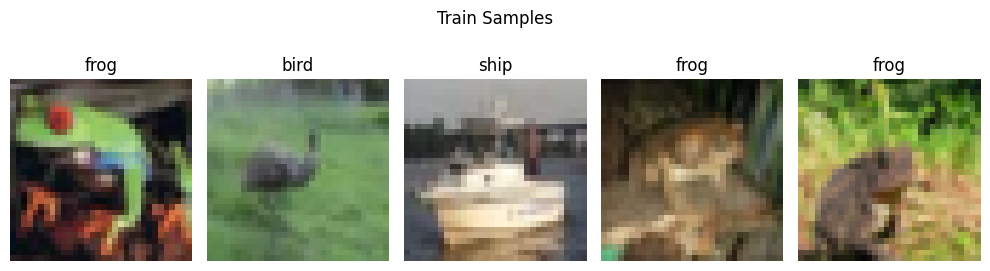

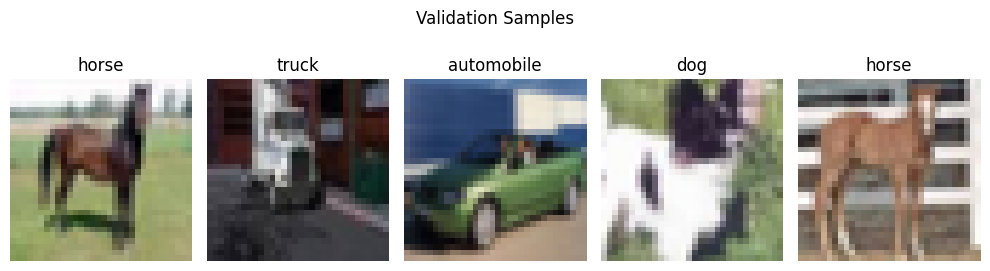

In [46]:
# %%
def save_figure(fig, filename):
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    return output_path

def show_images(dataset, num_images=5, title=""):
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes
    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()
        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")
    fig.tight_layout()
    return fig

fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png"); plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png"); plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32]) | Label: 6


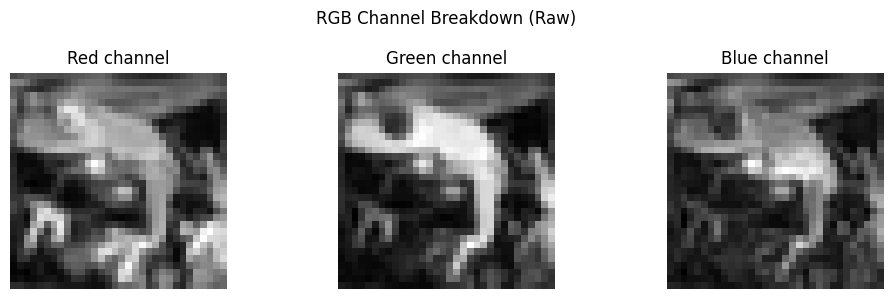

In [47]:
# %%
def debug_image_rgb(dataset):
    image, label = dataset[0] 
    print("Image shape (C, H, W):", image.shape, "| Label:", label)
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")
    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig

fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png"); plt.show()

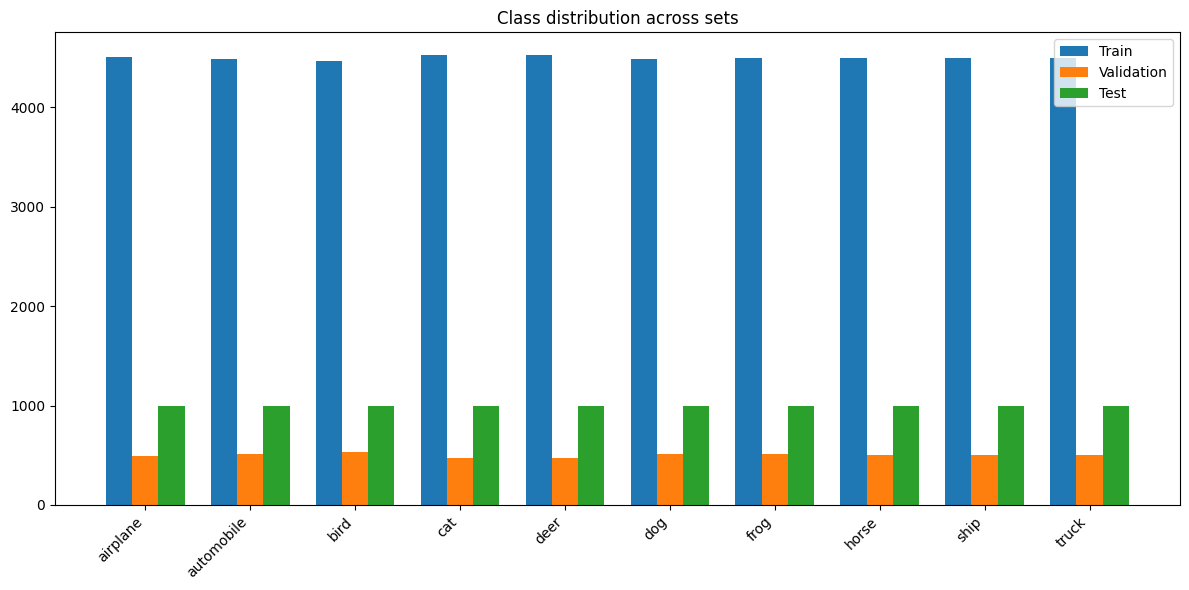

In [48]:
# %%
def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    label_names = test_dataset.classes
    num_classes = len(label_names)
    train_counts, val_counts, test_counts = np.zeros(num_classes), np.zeros(num_classes), np.zeros(num_classes)

    for idx in train_dataset.indices: train_counts[train_dataset.dataset.targets[idx]] += 1
    for idx in val_dataset.indices: val_counts[val_dataset.dataset.targets[idx]] += 1
    for label in test_dataset.targets: test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - bar_width, train_counts, width=bar_width, label="Train")
    ax.bar(x, val_counts, width=bar_width, label="Validation")
    ax.bar(x + bar_width, test_counts, width=bar_width, label="Test")

    ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_title("Class distribution across sets")
    ax.legend(); fig.tight_layout()
    return fig

fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png"); plt.show()

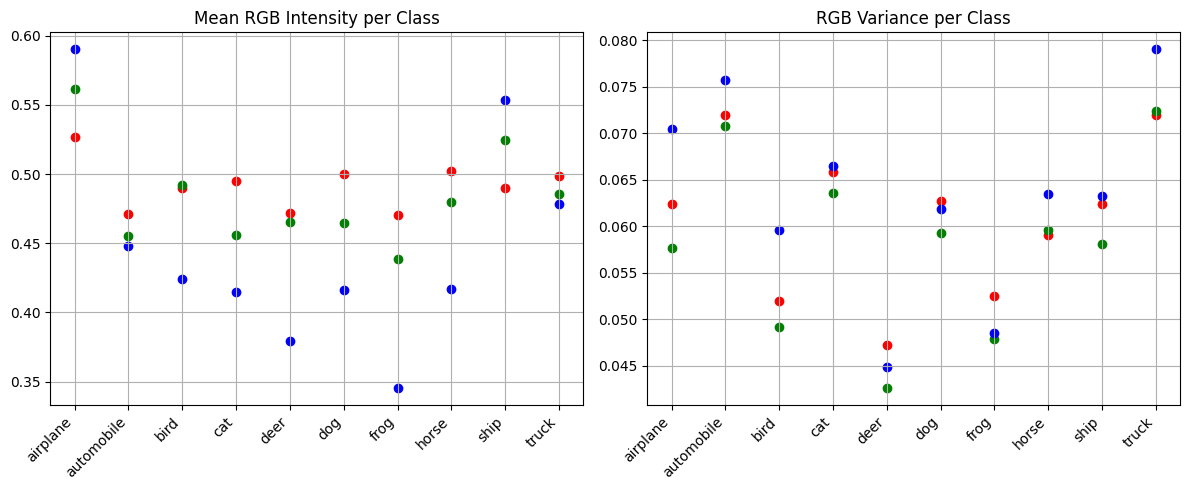

In [49]:
# %%
def compute_class_rgb_stats(dataset):
    num_classes = len(dataset.dataset.classes)
    pixel_sum, pixel_sq_sum, pixel_count = torch.zeros(num_classes, 3), torch.zeros(num_classes, 3), torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx] 
        img = img.view(3, -1) 
        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2
    return class_means.numpy(), class_vars.numpy()

def plot_rgb_stats(class_means, class_vars, class_names):
    x = np.arange(len(class_names))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = ['r', 'g', 'b']
    labels = ["Red", "Green", "Blue"]

    for i in range(3): axes[0].scatter(x, class_means[:, i], color=colors[i], label=labels[i])
    axes[0].set_title("Mean RGB Intensity per Class"); axes[0].set_xticks(x); axes[0].set_xticklabels(class_names, rotation=45, ha='right'); axes[0].grid(True)

    for i in range(3): axes[1].scatter(x, class_vars[:, i], color=colors[i])
    axes[1].set_title("RGB Variance per Class"); axes[1].set_xticks(x); axes[1].set_xticklabels(class_names, rotation=45, ha='right'); axes[1].grid(True)

    fig.tight_layout()
    return fig

class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)
save_figure(fig_rgb_stats, "rgb_stats_per_class.png"); plt.show()

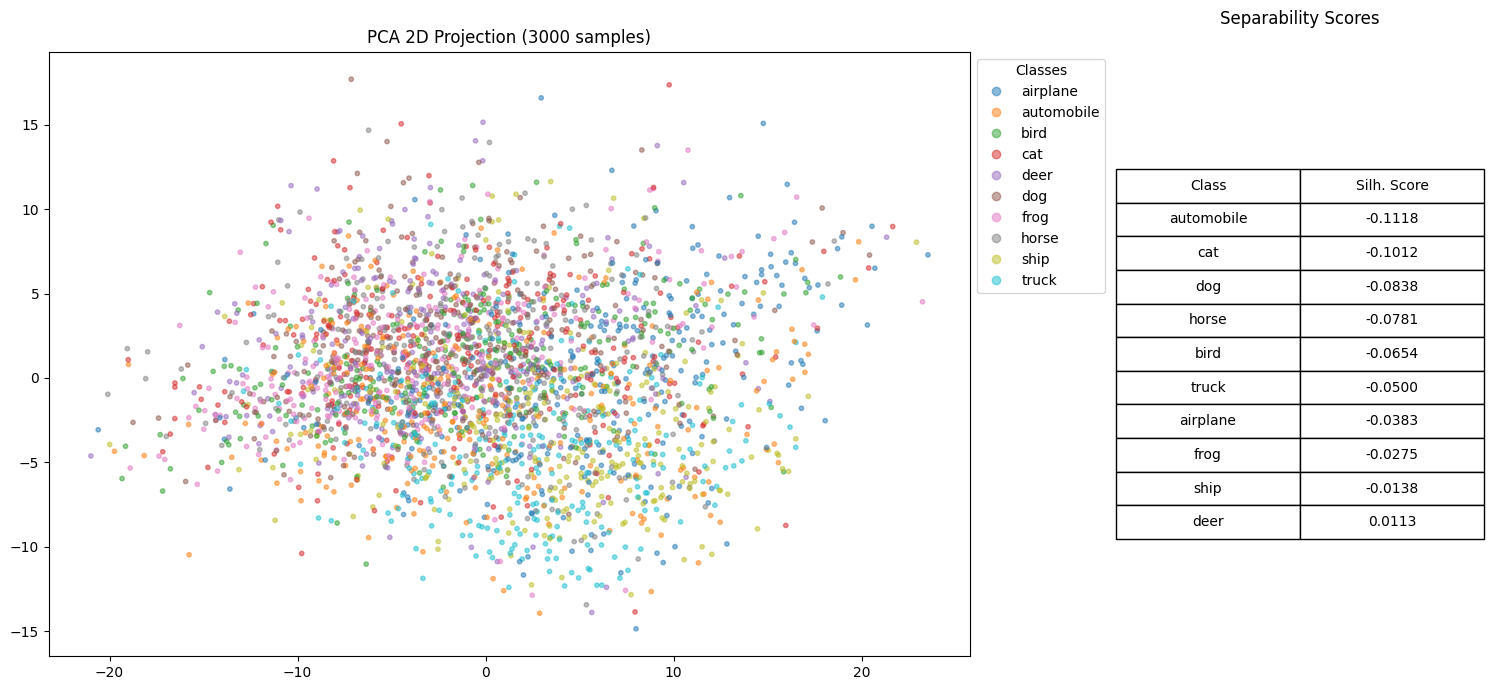

In [50]:
# %%
def plot_combined_analysis(dataset, num_samples=3000):
    images, labels = [], []
    for idx in dataset.indices[:num_samples]:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images, labels = np.array(images), np.array(labels)
    class_names = dataset.dataset.classes

    projected = PCA(n_components=2).fit_transform(images)
    sample_scores = silhouette_samples(images, labels)
    
    class_scores = [[class_names[i], f"{np.mean(sample_scores[labels == i]):.4f}"] for i in range(len(class_names))]
    class_scores.sort(key=lambda x: float(x[1]))

    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")

    ax_table.axis('off')
    table = ax_table.table(cellText=class_scores, colLabels=["Class", "Silh. Score"], loc='center', cellLoc='center')
    table.scale(1.2, 1.8); ax_table.set_title("Separability Scores", pad=20)
    fig.tight_layout()
    return fig

fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png"); plt.show()

In [51]:
# %%
def init_weights(model, init_type='kaiming'):
    def init_func(m):
        if isinstance(m, nn.Linear):
            if init_type == 'kaiming': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'xavier': nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
    model.apply(init_func)

def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device=device, scheduler=None, exp_name="Experiment", trial=None):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "stop_reason": "completed"}
    best_val_loss, best_val_acc, patience_counter = float('inf'), 0.0, 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        if scheduler is not None: scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)

        if val_loader:
            model.eval()
            val_running_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for v_in, v_lab in val_loader:
                    v_in, v_lab = v_in.to(device), v_lab.to(device)
                    v_out = model(v_in)
                    val_running_loss += loss_fn(v_out, v_lab).item() * v_in.size(0)
                    _, v_pred = v_out.max(1)
                    total_val += v_lab.size(0)
                    correct_val += v_pred.eq(v_lab).sum().item()

            val_loss = val_running_loss / len(val_loader.dataset)
            val_acc = correct_val / total_val
            history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), MODEL_SAVE_DIR / f"{exp_name}_best.pth")

            if trial is not None:
                trial.report(val_acc, epoch)
                if trial.should_prune(): raise optuna.exceptions.TrialPruned()

            if trial is None:
                if epoch == 7 and val_acc < 0.35:
                    print(f"⚠️ [{exp_name}] Pruned: Poor performance at epoch 8")
                    history["stop_reason"] = "pruned_bad_start"; break

                if val_loss < best_val_loss: best_val_loss = val_loss; patience_counter = 0 
                else: patience_counter += 1

                massive_overfit = (val_loss - train_loss) > 0.8 
                if patience_counter >= 5 or massive_overfit:
                    reason = "massive_divergence" if massive_overfit else "patience_exceeded"
                    print(f"🛑 [{exp_name}] Early Stopped ({reason}).")
                    history["stop_reason"] = f"early_stopped_overfit_{reason}"; break

    return history

def test(model, test_loader, loss_fn, device=device):
    model.to(device); model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += loss_fn(outputs, labels).item() * inputs.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    return test_loss / len(test_loader.dataset), correct / total

In [52]:
# %%
class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10, activation_name='relu'):
        super(VanillaMLP, self).__init__()
        acts = {'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 'gelu': nn.GELU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()}
        activation = acts.get(activation_name.lower(), nn.ReLU())

        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(activation)
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

In [53]:
# %%
def plot_training_results(results_dict, exp_name=None):
    if exp_name is None: exp_name = list(results_dict.keys())[-1]
    data = results_dict[exp_name]
    history = data['history']
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Performance: {exp_name}', fontsize=16, fontweight='bold')

    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    ax1.set_title('Cross Entropy Loss'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 's-', label='Val Acc')
    ax2.set_title('Accuracy Score'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)

    val_acc_val = float(history['val_acc'][-1]) if history['val_acc'] else 0.0
    fig.text(0.5, 0.02, f"Final Val Acc: {val_acc_val:.4f} | Stop Reason: {history['stop_reason']}", ha='center')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(OUTPUTS_DIR / f"{exp_name}_performance.png", dpi=300, bbox_inches='tight')
    plt.show()

In [54]:
# %%
print("🚀 Starting Phase A: Focused Grid Search...")

if RESULTS_PATH.exists():
    print(f"📂 Found existing results file. Resuming from {RESULTS_PATH}...")
    with open(RESULTS_PATH, "rb") as f: results_log = pickle.load(f)
else:
    results_log = {}

grid_params = {
    "hidden_dims": [[1024], [512, 256], [1024, 512, 128], [1024, 512, 256, 128]], 
    "activation": ["relu", "leaky_relu", "sigmoid"], 
    "lr": [1e-2, 1e-3, 5e-4, 1e-4, 1e-5],                          
    "scheduler": ["none", "cosine", "step"]                          
}

keys, values = zip(*grid_params.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

batch_size = 128; epochs = 50
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for i, config in enumerate(experiments):
    act, lr, sch = config['activation'], config['lr'], config['scheduler']
    exp_name = f"Exp_{i:03d}_L{len(config['hidden_dims'])}_W{config['hidden_dims'][0]}_{act}_lr{lr}_{sch}"
    
    if exp_name in results_log:
        print(f"⏩ Skipping {exp_name} (already completed).")
        continue

    print(f"\n🔹 Running {exp_name} ({i+1}/{len(experiments)})")
    model = VanillaMLP(hidden_dims=config["hidden_dims"], activation_name=act).to(device)
    init_weights(model, init_type='xavier' if act == "sigmoid" else 'kaiming')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    config["optimizer"] = "adam"

    if sch == "step": scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    elif sch == "cosine": scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else: scheduler = None

    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs, device=device, scheduler=scheduler, exp_name=exp_name)
    results_log[exp_name] = {"config": config, "history": history}
    
    with open(RESULTS_PATH, "wb") as f: pickle.dump(results_log, f)

print(f"\n🎉 All Grid Search runs completed successfully!")

🚀 Starting Phase A: Focused Grid Search...
📂 Found existing results file. Resuming from /home/raveco/deep_learning_ass1/outputs/phase_a_grid_results.pkl...
⏩ Skipping Exp_000_L1_W1024_relu_lr0.01_none (already completed).
⏩ Skipping Exp_001_L1_W1024_relu_lr0.01_cosine (already completed).
⏩ Skipping Exp_002_L1_W1024_relu_lr0.01_step (already completed).
⏩ Skipping Exp_003_L1_W1024_relu_lr0.001_none (already completed).
⏩ Skipping Exp_004_L1_W1024_relu_lr0.001_cosine (already completed).
⏩ Skipping Exp_005_L1_W1024_relu_lr0.001_step (already completed).
⏩ Skipping Exp_006_L1_W1024_relu_lr0.0005_none (already completed).
⏩ Skipping Exp_007_L1_W1024_relu_lr0.0005_cosine (already completed).
⏩ Skipping Exp_008_L1_W1024_relu_lr0.0005_step (already completed).
⏩ Skipping Exp_009_L1_W1024_relu_lr0.0001_none (already completed).
⏩ Skipping Exp_010_L1_W1024_relu_lr0.0001_cosine (already completed).
⏩ Skipping Exp_011_L1_W1024_relu_lr0.0001_step (already completed).
⏩ Skipping Exp_012_L1_W1024_r

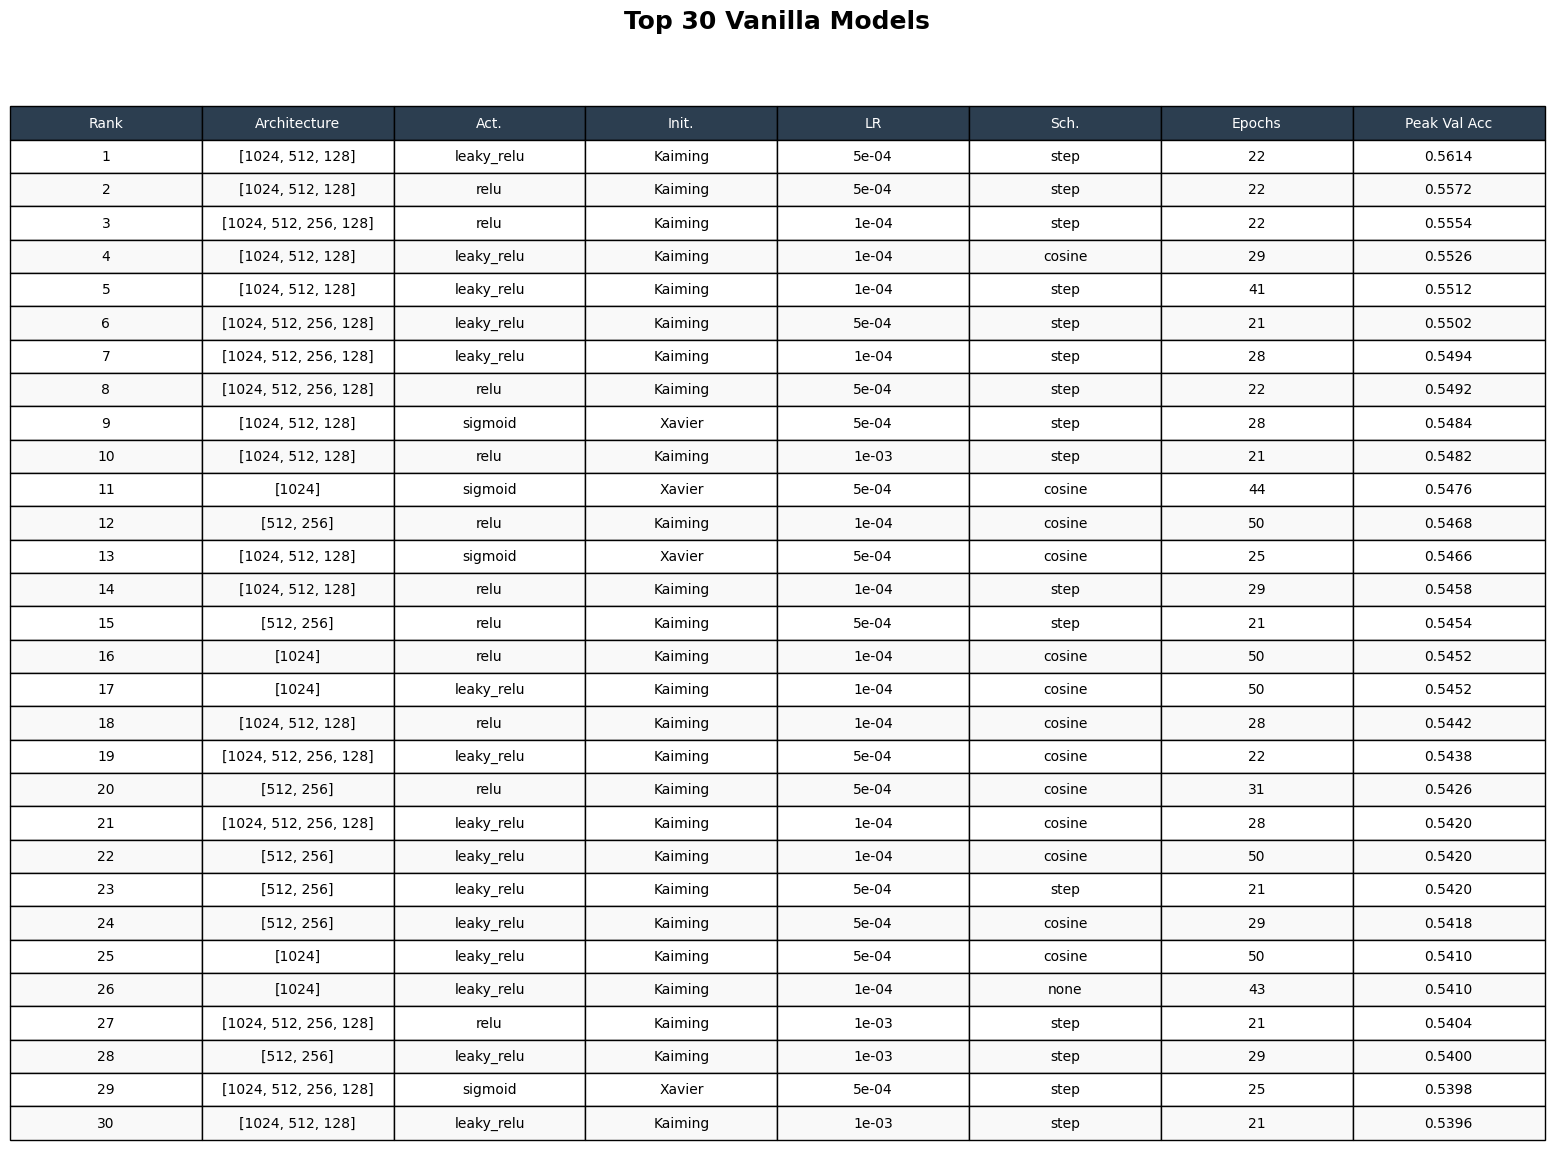

In [61]:
# %%
# %%
def analyze_top_results(results_path, top_n=30):
    if not results_path.exists(): return
    with open(results_path, "rb") as f: log = pickle.load(f)

    summary_data = []
    for name, data in log.items():
        c, h = data['config'], data['history']
        val_accs = h.get('val_acc', [])
        
        # Determine init based on the exact logic executed in the script
        act_name = c['activation'].lower()
        init_method = "Xavier" if act_name == "sigmoid" else "Kaiming"
        
        summary_data.append({
            "Architecture": str(c['hidden_dims']),
            "Act.": act_name,
            "Init.": init_method,
            "LR": f"{c['lr']:.0e}",
            "Sch.": c['scheduler'],
            "Epochs": len(val_accs),
            "Peak Val Acc": max(val_accs) if val_accs else 0
        })

    # Sort, take top N, and reset index
    df = pd.DataFrame(summary_data).sort_values(by="Peak Val Acc", ascending=False).head(top_n).reset_index(drop=True)
    
    # Insert Rank column at the very beginning
    df.insert(0, 'Rank', df.index + 1)
    
    # Format accuracy
    df['Peak Val Acc'] = df['Peak Val Acc'].map(lambda x: f"{x:.4f}")

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 14)); ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.scale(1.1, 2.0)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0: 
            cell.get_text().set_color('white')
            cell.set_facecolor('#2c3e50')
        elif row % 2 == 0: 
            cell.set_facecolor('#f9f9f9')

    plt.title(f"Top {top_n} Vanilla Models", fontsize=18, fontweight='bold', pad=40)
    plt.savefig(OUTPUTS_DIR / "top_30_vanilla.png", dpi=300, bbox_inches='tight')
    plt.show()

analyze_top_results(RESULTS_PATH)

🏆 Best Model Found: Exp_113_L3_W1024_leaky_relu_lr0.0005_step
⭐ Peak Validation Accuracy: 0.5614


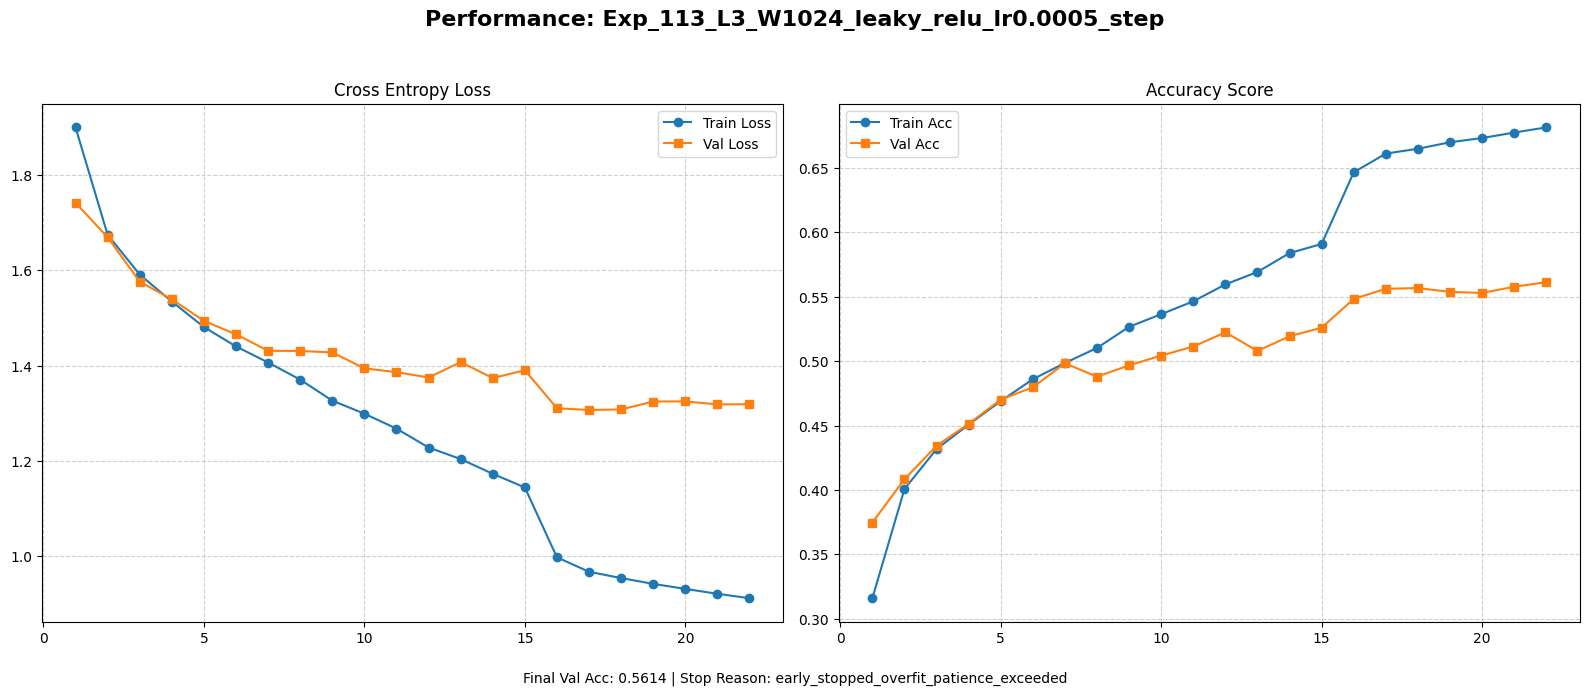

In [63]:
# %% [markdown]
# ## Plot Best Ranked Vanilla Model
# Automatically finds the top-performing model from Phase A and visualizes its training curves.

# %%
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "rb") as f:
        results_log = pickle.load(f)

    # Find the experiment with the maximum peak validation accuracy
    best_exp_name = None
    best_val_acc = -1

    for exp_name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [0])
        peak_acc = max(val_accs) if val_accs else 0
        
        if peak_acc > best_val_acc:
            best_val_acc = peak_acc
            best_exp_name = exp_name

    print(f"🏆 Best Model Found: {best_exp_name}")
    print(f"⭐ Peak Validation Accuracy: {best_val_acc:.4f}")

    # Plot using your existing function from Cell 11
    plot_training_results(results_log, exp_name=best_exp_name)
else:
    print(f"❌ Results file not found at {RESULTS_PATH}")

In [66]:
# %% [markdown]
# ## Phase A: Final Test Set Evaluation
# Evaluating the Chosen VanillaMLP on the unseen test dataset.

# %%
if 'best_exp_name' in locals() and best_exp_name:
    print(f"Loading best baseline model: {best_exp_name}")
    
    # --- FIX: Initialize the test_loader ---
    # We use a batch size of 128 (same as training) and shuffle=False for testing
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    # 1. Reconstruct the best configuration from the log
    best_config = results_log[best_exp_name]['config']
    
    # 2. Initialize the model with these exact parameters
    chosen_vanilla_model = VanillaMLP(
        hidden_dims=best_config['hidden_dims'], 
        activation_name=best_config['activation']
    ).to(device)
    
    # 3. Load the saved best weights
    weights_path = MODEL_SAVE_DIR / f"{best_exp_name}_best.pth"
    chosen_vanilla_model.load_state_dict(torch.load(weights_path, map_location=device))
    
    # 4. Evaluate on the test set using your existing test() function
    loss_fn = nn.CrossEntropyLoss()
    test_loss, test_acc = test(chosen_vanilla_model, test_loader, loss_fn, device=device)
    
    print("\n" + "="*50)
    print("🏆 Final Vanilla MLP Test Set Metrics")
    print("="*50)
    print(f"i.  Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
    print(f"ii. Loss:     {test_loss:.4f}")
    print("="*50)
else:
    print("❌ Could not find 'best_exp_name'. Please run the previous cell first.")

Loading best baseline model: Exp_113_L3_W1024_leaky_relu_lr0.0005_step

🏆 Final Vanilla MLP Test Set Metrics
i.  Accuracy: 0.5497 (54.97%)
ii. Loss:     1.3084


In [67]:
# %% [markdown]
# ## Phase B: Dynamic Normalization & Transforms

# %%
temp_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)
mean, std = 0.0, 0.0
for images, _ in temp_loader:
    images = images.view(images.size(0), images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

mean /= len(train_dataset); std /= len(train_dataset)

train_transform_improved = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

test_transform_improved = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

print("✅ Data re-loaded with improved transforms and normalization.")

✅ Data re-loaded with improved transforms and normalization.
